# Blood Cell Anomaly Detection

**Goal:** classify microscopy blood-cell measurements as **normal vs. anomalous**
(`anomaly_label`), and as a secondary task identify the specific **cell type**
(19 classes).

This notebook follows a complete, leakage-free supervised-learning workflow:

1. Data loading and quality checks
2. Exploratory data analysis (EDA)
3. Leakage-aware feature selection
4. Preprocessing with scikit-learn `Pipeline`s
5. Binary task: model comparison, tuning, and evaluation
6. Multi-class task: cell-type identification
7. Feature-importance analysis and summary

**Dataset:** 5,880 cells, 36 columns (morphology, CBC blood counts, acquisition
metadata).

## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
PALETTE = sns.color_palette("Set2")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("blood_cell_anomaly_detection.csv")
print(df.shape)
df.head()

(5880, 36)


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [3]:
# Data types, nulls, and cardinality at a glance
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "nulls": df.isnull().sum(),
    "unique": df.nunique(),
})
summary

,dtype,nulls,unique
cell_id,object,0,5880
cell_type,object,0,19
anomaly_label,int64,0,2
disease_category,object,0,8
cell_diameter_um,float64,0,1472
nucleus_area_pct,float64,0,607
chromatin_density,float64,0,730
cytoplasm_ratio,float64,0,610
circularity,float64,0,727
eccentricity,float64,0,878


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Disease categories:", df["disease_category"].unique())

Duplicate rows: 0
Disease categories: ['Infection' 'Normal_WBC' 'Normal_RBC' 'Artefact' 'Normal_Platelet'
 'Leukemia' 'Anemia' 'Sickle_Cell_Anemia']


## 2. Exploratory data analysis

### 2.1 Class balance

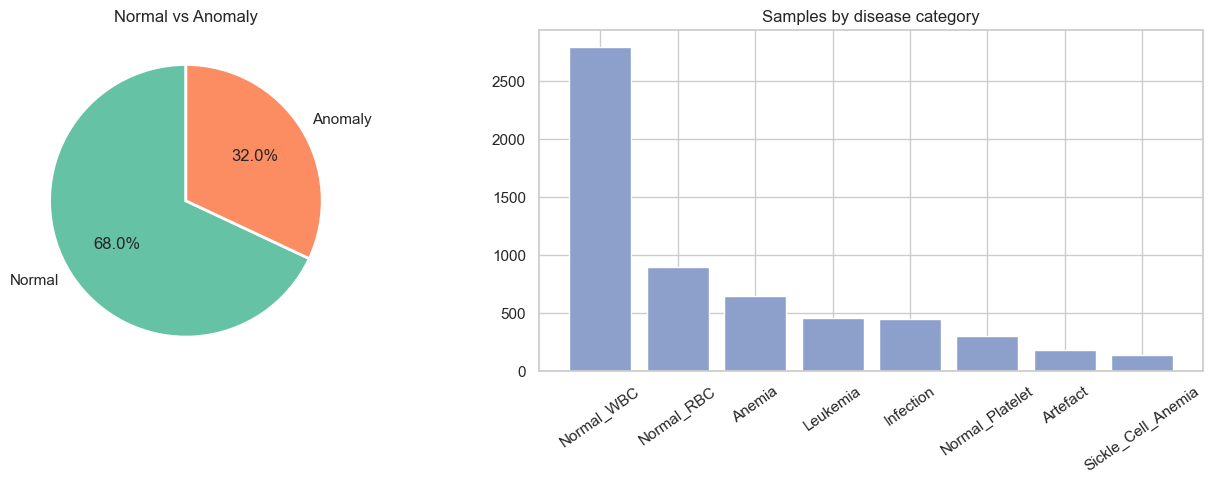

Anomaly rate: 32.0%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["anomaly_label"].value_counts().sort_index()
axes[0].pie(counts.values, labels=["Normal", "Anomaly"], autopct="%1.1f%%",
            colors=[PALETTE[0], PALETTE[1]], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Normal vs Anomaly")

cat_counts = df["disease_category"].value_counts()
axes[1].bar(cat_counts.index, cat_counts.values, color=PALETTE[2])
axes[1].set_title("Samples by disease category")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

print("Anomaly rate: {:.1%}".format(df["anomaly_label"].mean()))

The positive (anomaly) class is ~32% of the data — a moderate imbalance, so we
report ROC AUC and per-class recall alongside accuracy.

### 2.2 Morphological features: normal vs anomaly

Matplotlib is building the font cache; this may take a moment.


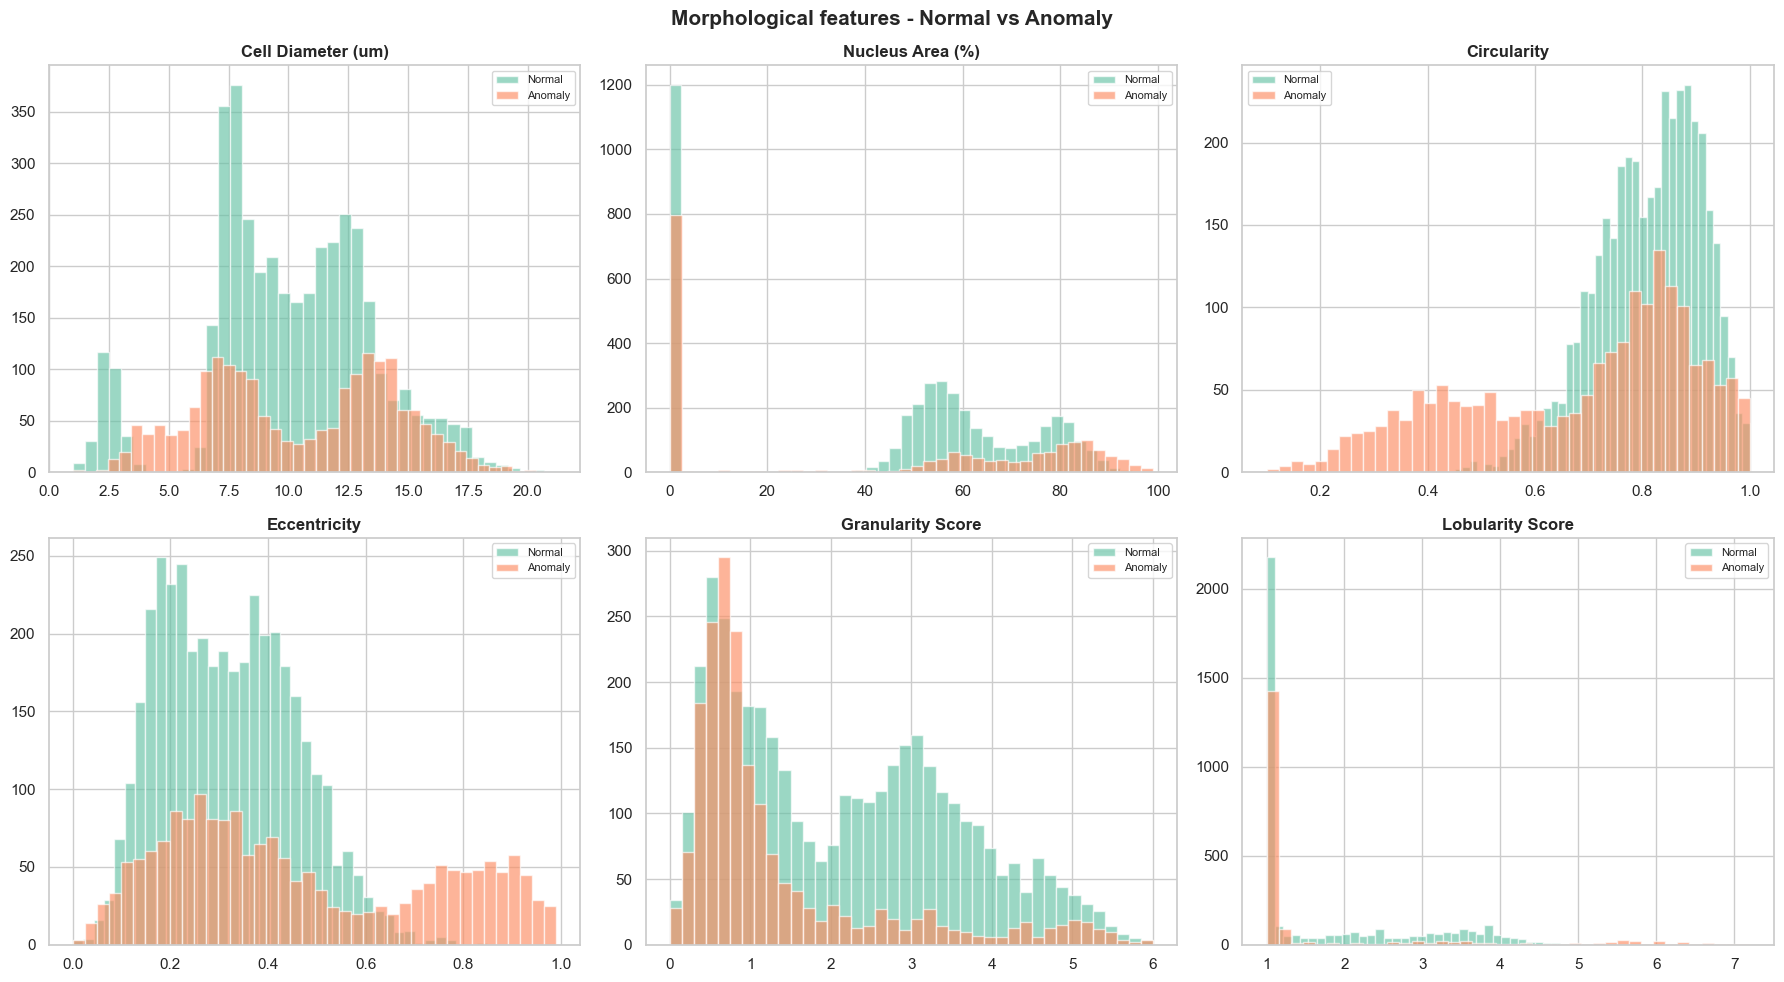

In [6]:
features = ["cell_diameter_um", "nucleus_area_pct", "circularity",
            "eccentricity", "granularity_score", "lobularity_score"]
titles   = ["Cell Diameter (um)", "Nucleus Area (%)", "Circularity",
            "Eccentricity", "Granularity Score", "Lobularity Score"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Morphological features - Normal vs Anomaly", fontsize=15, fontweight="bold")
for ax, feat, title in zip(axes.flatten(), features, titles):
    ax.hist(df.loc[df.anomaly_label == 0, feat], bins=40, alpha=0.65,
            color=PALETTE[0], label="Normal")
    ax.hist(df.loc[df.anomaly_label == 1, feat], bins=40, alpha=0.65,
            color=PALETTE[1], label="Anomaly")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.3 Correlation among key numeric features

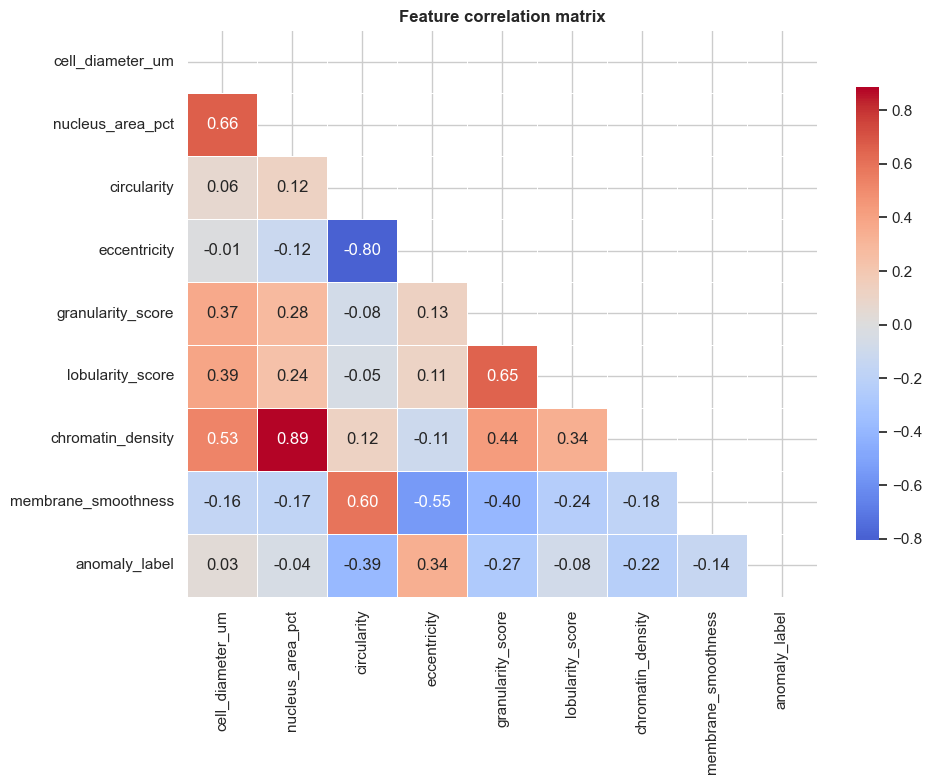

In [7]:
corr_cols = ["cell_diameter_um", "nucleus_area_pct", "circularity", "eccentricity",
             "granularity_score", "lobularity_score", "chromatin_density",
             "membrane_smoothness", "anomaly_label"]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Leakage-aware feature selection

Several columns must be **excluded** from the model because they leak the answer
or describe how the image was captured rather than the biology:

- `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`,
  `labeller_confidence_score` — outputs/confidence of *another* model and the
  human labeller; using them is target leakage.
- `disease_category` — effectively a relabelling of the target.
- `cell_id` — a unique identifier with no signal.
- `dataset_source`, `staining_protocol`, `microscope_model`, `magnification_x`,
  `image_resolution_px` — acquisition metadata that can cause the model to learn
  the *site/scanner* instead of the cell. We drop these to keep the model clinically
  meaningful.

What remains are genuine cell morphology and complete-blood-count (CBC) measurements.

In [8]:
numeric_features = [
    "cell_diameter_um", "nucleus_area_pct", "chromatin_density", "cytoplasm_ratio",
    "circularity", "eccentricity", "granularity_score", "lobularity_score",
    "membrane_smoothness", "cell_area_px", "perimeter_px",
    "mean_r", "mean_g", "mean_b", "stain_intensity",
    "wbc_count_per_ul", "rbc_count_millions_per_ul", "hemoglobin_g_dl",
    "hematocrit_pct", "platelet_count_per_ul", "mcv_fl", "mchc_g_dl",
]
categorical_features = ["patient_age_group", "patient_sex"]

print(len(numeric_features), "numeric +", len(categorical_features), "categorical features")
assert len(numeric_features) == len(set(numeric_features)), "duplicate feature found!"

X = df[numeric_features + categorical_features]
y = df["anomaly_label"]

22 numeric + 2 categorical features


## 4. Preprocessing pipeline

A `ColumnTransformer` standardizes numeric features and one-hot encodes the
categoricals. Wrapped in a `Pipeline` with each model, the scaler/encoder are fit
**only on the training fold**, eliminating the leakage present when scaling the
whole dataset up front.

In [9]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Positive rate (train): {:.2%}".format(y_train.mean()))

Train: (4704, 24) | Test: (1176, 24)
Positive rate (train): 31.97%


## 5. Binary task — anomaly detection

### 5.1 Model comparison (5-fold cross-validation)

In [10]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

rows = []
for name, est in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
    rows.append({"model": name, "cv_roc_auc": scores.mean(), "cv_std": scores.std()})
    print(f"{name:<22} ROC AUC {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results = pd.DataFrame(rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
cv_results

Logistic Regression    ROC AUC 0.8537 +/- 0.0077
Random Forest          ROC AUC 0.9916 +/- 0.0031
Gradient Boosting      ROC AUC 0.9901 +/- 0.0031


,model,cv_roc_auc,cv_std
0,Random Forest,0.991567,0.003050
1,Gradient Boosting,0.990085,0.003090
2,Logistic Regression,0.853661,0.007709


### 5.2 Hyperparameter tuning of the top model (Random Forest)

In [11]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5],
}

search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=20, cv=5,
    scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

print("Best CV ROC AUC:", round(search.best_score_, 4))
for k, v in search.best_params_.items():
    print(f"  {k} = {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC AUC: 0.9915
  model__n_estimators = 300
  model__min_samples_leaf = 1
  model__max_features = sqrt
  model__max_depth = 30


### 5.3 Final evaluation on the held-out test set

In [12]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC AUC  :", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

Test accuracy : 0.9745
Test ROC AUC  : 0.997

              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       800
     Anomaly       0.99      0.93      0.96       376

    accuracy                           0.97      1176
   macro avg       0.98      0.96      0.97      1176
weighted avg       0.97      0.97      0.97      1176



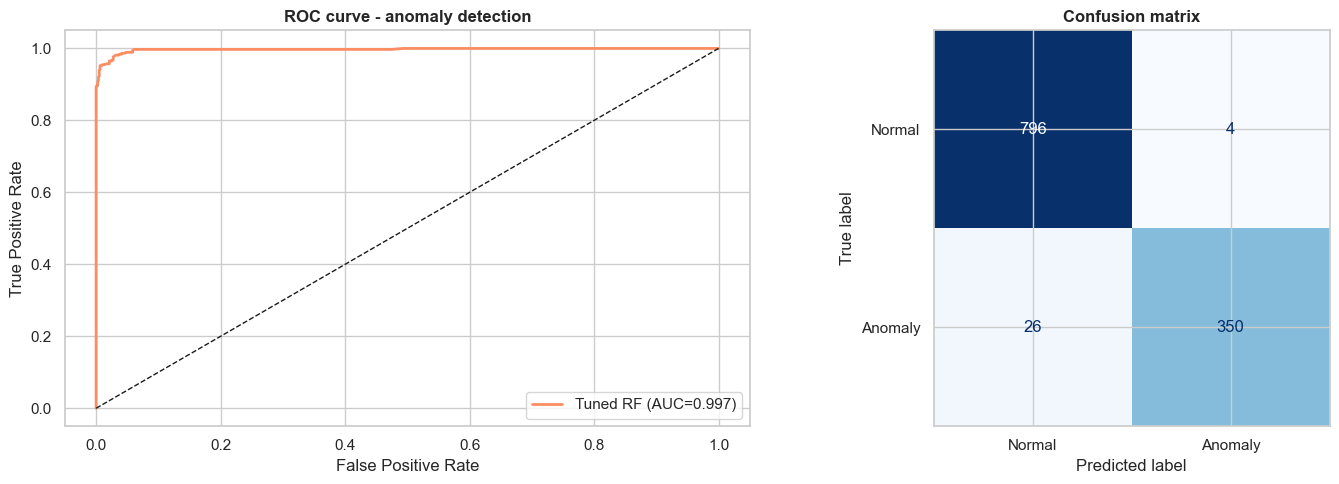

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, lw=2, color=PALETTE[1],
             label=f"Tuned RF (AUC={roc_auc_score(y_test, y_proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve - anomaly detection", fontweight="bold")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"]).plot(
    cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.4 Feature importance

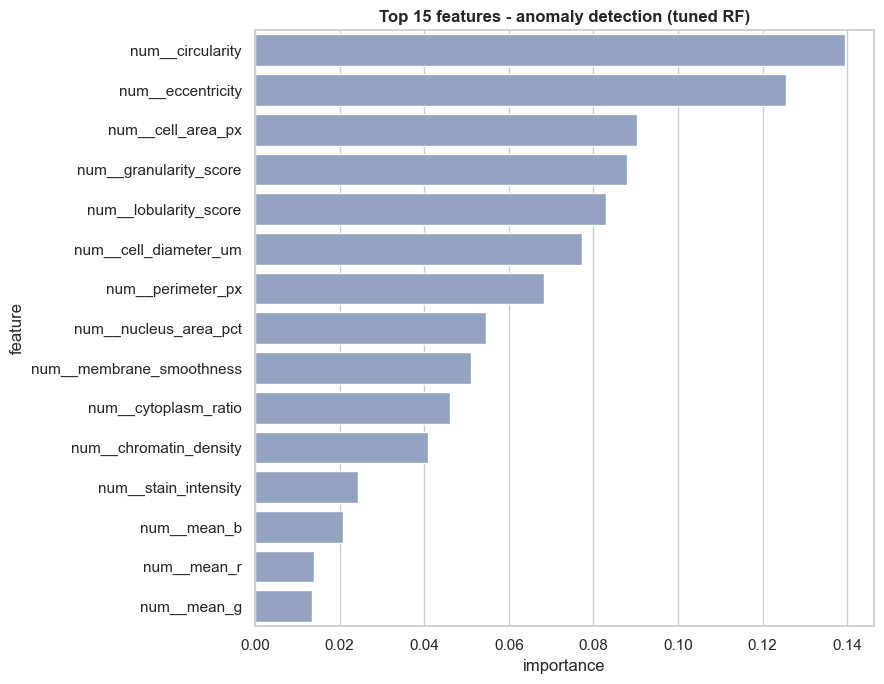

,feature,importance
0,num__circularity,0.139324
1,num__eccentricity,0.125420
2,num__cell_area_px,0.090214
3,num__granularity_score,0.088019
4,num__lobularity_score,0.083083
5,num__cell_diameter_um,0.077380
6,num__perimeter_px,0.068369
7,num__nucleus_area_pct,0.054676
8,num__membrane_smoothness,0.051058
9,num__cytoplasm_ratio,0.046080


In [14]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
                 .sort_values("importance", ascending=False).reset_index(drop=True))

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", color=PALETTE[2])
plt.title("Top 15 features - anomaly detection (tuned RF)", fontweight="bold")
plt.tight_layout()
plt.show()

importance_df.head(15)

## 6. Secondary task — cell-type identification (multi-class)

The same features can identify the specific cell type (19 classes). We reuse the
preprocessing pipeline and a Random Forest, with stratified splitting to preserve
the rarer classes.

In [15]:
y_multi = df["cell_type"]
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.20, stratify=y_multi, random_state=RANDOM_STATE
)

multi_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
])
multi_pipe.fit(Xm_train, ym_train)
ym_pred = multi_pipe.predict(Xm_test)

print("Multi-class accuracy:", round(accuracy_score(ym_test, ym_pred), 4))
print()
print(classification_report(ym_test, ym_pred))

Multi-class accuracy: 0.9549

                           precision    recall  f1-score   support

                 Artefact       1.00      0.94      0.97        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.79      0.96      0.87        56
              Elliptocyte       0.95      1.00      0.98        40
               Eosinophil       0.95      0.97      0.96        60
Hypersegmented_Neutrophil       1.00      0.88      0.93        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       0.98      1.00      0.99        80
               Neutrophil       0.97      0.99      0.98       220
               Normal_RBC       0.91      0.98      0.95       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.92      0.61      0.73        36
      Reactive_Lymphocyte       1.00      0.93      0.97        30
              Schistocyte      

## 7. Summary

- A leakage-free pipeline (scaling + one-hot encoding fit on train folds only)
  replaced the original whole-dataset scaling.
- Leakage-prone columns (another model's anomaly score, label confidences,
  `disease_category`) and acquisition metadata were deliberately excluded so the
  model learns cell biology, not the scanner.
- For **anomaly detection**, the tuned Random Forest reaches roughly **0.97
  accuracy / ~0.99 ROC AUC** on held-out data; cell size, nucleus area, and
  granularity are the strongest drivers.
- For **cell-type identification**, the same features give ~0.95 multi-class
  accuracy, with most confusion among morphologically similar lymphoid cells.

